# Step 2: Exploratory Data Analysis

**What we're doing:** Looking at distributions, correlations, and
relationships in the data visually and numerically, before touching any
model.

**Why this matters (and isn't just 'make some charts'):** EDA is where you
build intuition for what a model SHOULD find. If your model later says
tenure doesn't matter, but your EDA showed a strong tenure-churn relationship,
that's a red flag worth investigating — not something to ignore. EDA is
also how you catch data leakage and weird distributions before they quietly
wreck your model.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/MyDrive/churn-platform'

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

df = pd.read_csv(f'{PROJECT_ROOT}/data/processed/churn_clean.csv')
df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(7043, 21)

## 2.1 Target distribution
First question always: is the target balanced or imbalanced? This affects
every later choice — which metric to optimize (accuracy is misleading on
imbalanced data), whether to resample, and how to interpret model output.

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


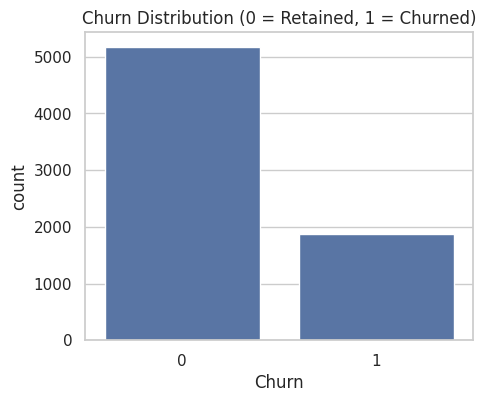

In [3]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution (0 = Retained, 1 = Churned)')
plt.show()

# At ~73/27 split, this is moderately imbalanced — not extreme, but enough
# that we should track precision/recall/AUC later, not just accuracy.
# A model that always predicts "no churn" would already be ~73% "accurate"
# while being completely useless.

## 2.2 Numeric feature distributions by churn status
We overlay churned vs retained customers on the same chart so differences
in distribution shape are visible at a glance, not just in summary stats.

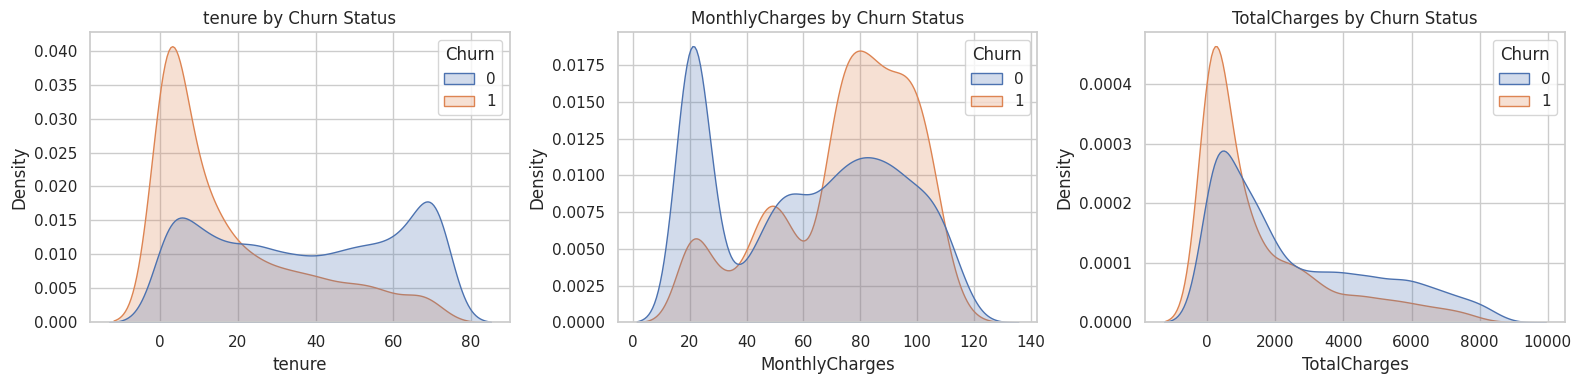

In [4]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, ax=ax)
    ax.set_title(f'{col} by Churn Status')
plt.tight_layout()
plt.show()

# What to look for: if the churned (1) and retained (0) curves are nearly
# identical, that feature probably has little predictive power. If they're
# clearly shifted apart, that's a strong candidate predictor.

## 2.3 Correlation heatmap (numeric features)
**Why a heatmap specifically:** a table of correlation numbers is hard to
scan; color makes strong relationships jump out immediately, and it helps
you catch multicollinearity (two features so correlated with each other
that including both adds noise, not signal) before modeling.

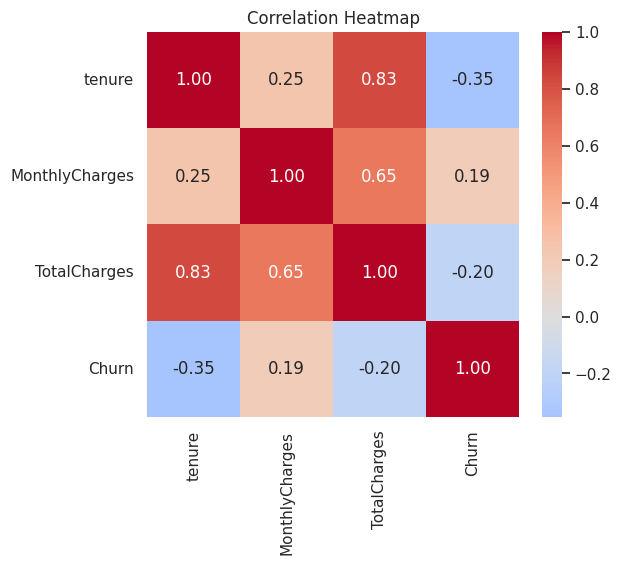

In [5]:
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Expect: tenure and TotalCharges will be highly correlated (longer tenure
# = more total charges, almost by definition). That's a multicollinearity
# flag worth noting for linear-model assumptions, though tree-based models
# (XGBoost/Random Forest) are robust to it.

## 2.4 Categorical feature breakdown
Bar charts of churn rate per category, across the most business-relevant
categorical columns.

/tmp/ipykernel_2641/281717823.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate_by_cat.values, y=churn_rate_by_cat.index, ax=ax, palette='Reds_r')
/tmp/ipykernel_2641/281717823.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate_by_cat.values, y=churn_rate_by_cat.index, ax=ax, palette='Reds_r')
/tmp/ipykernel_2641/281717823.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate_by_cat.values, y=churn_rate_by_cat.index, ax=ax, palette='Reds_r')
/tmp/ipykernel_2641/281717823.py:6: FutureWarning: 

Passing 

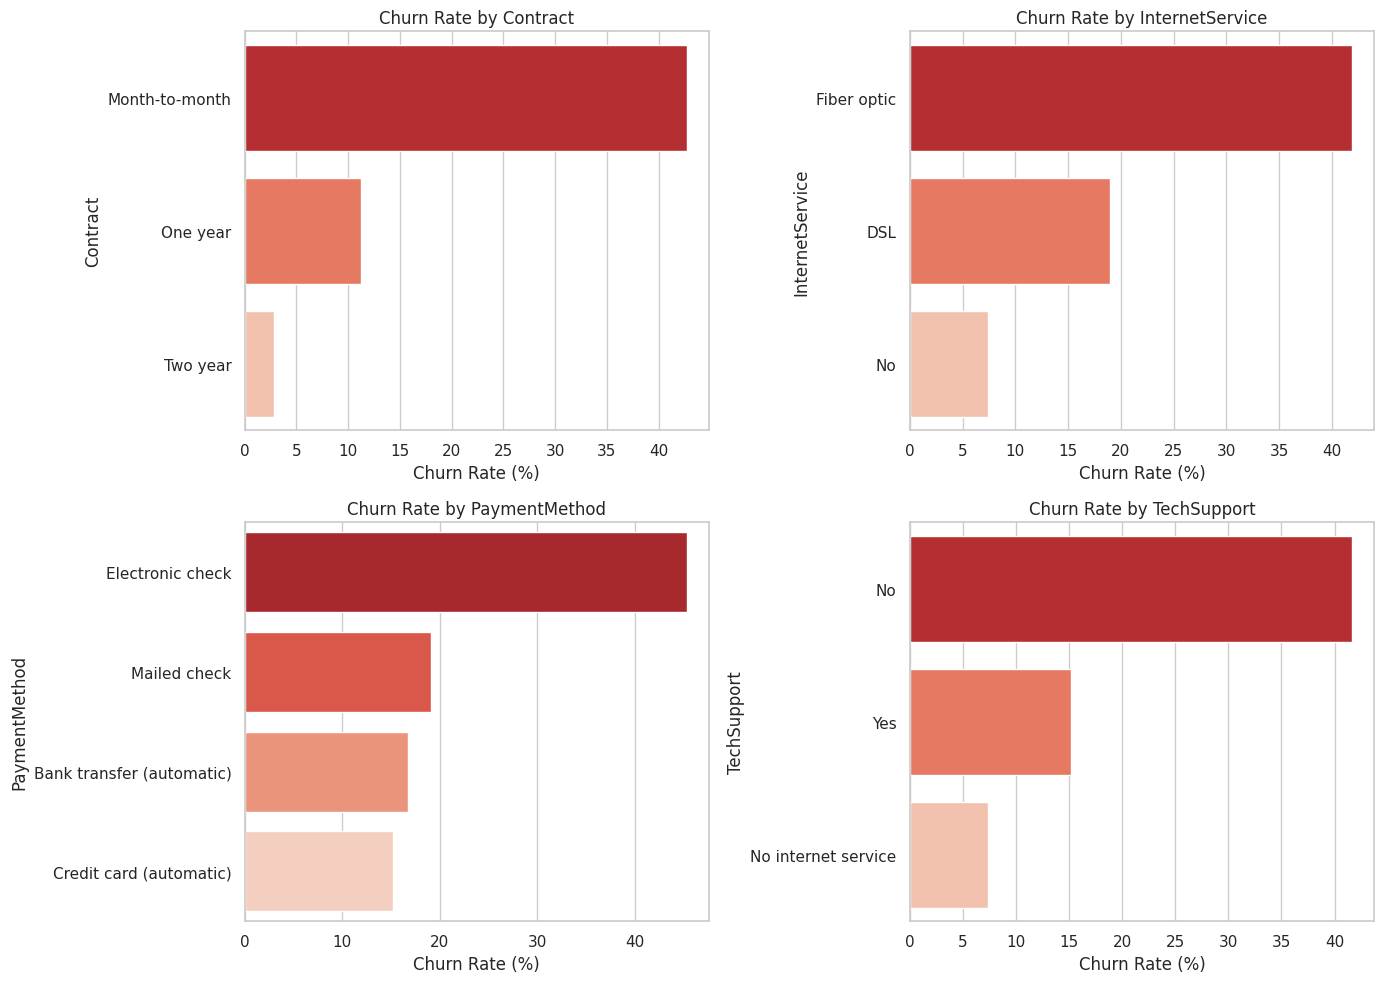

In [6]:
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), categorical_cols):
    churn_rate_by_cat = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=churn_rate_by_cat.values, y=churn_rate_by_cat.index, ax=ax, palette='Reds_r')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_title(f'Churn Rate by {col}')
plt.tight_layout()
plt.show()

## 2.5 Missing value check
We already handled `TotalCharges` in Step 1, but this is the formal,
documented check — always re-verify on the dataset you're actually about
to model on, not just the raw one.

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing values per column:' if len(missing) else 'No missing values remain.')
print(missing)

No missing values remain.
Series([], dtype: int64)


## 2.6 EDA takeaways (fill in after running)
Write 3-5 bullet points here summarizing what you found. This becomes the
raw material for your README's findings section. Example structure:
- Target is moderately imbalanced (~73/27) → use AUC/precision/recall, not just accuracy
- Month-to-month contracts churn at a much higher rate than 1-2yr contracts
- Tenure and TotalCharges are highly correlated → expected, watch for multicollinearity in linear models
- Customers without TechSupport/OnlineSecurity churn more — these may indicate engagement, not causation